### Project By- Pranali for DASA TECHNOWORLD PVT. LTD.

# Price Prediction

## Objective

The objective of this notebook is to build regression models that predict farm revenue using historical farm and production data.

The notebook includes:

- Loading processed farm data
- Training multiple regression models
- Comparing model performance
- Evaluating prediction accuracy
- Visualizing Actual vs Predicted values
- Analyzing residual errors
- Identifying important features
- Saving the final modelBuild regression model
Predict crop price / revenue
Evaluate RMSE & R²
Save trained model

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

sns.set_style("whitegrid")

In [2]:
# ============================================================
# Load Feature Engineered Dataset
# ============================================================

df = pd.read_csv("../data/processed/farm_ml_clean_data.csv")

print("Dataset Shape :", df.shape)

display(df.head())

Dataset Shape : (22917, 17)


,Farmer_ID,State,Farm_Size_Birds,Experience_Years,Join_Date,Contract_Type,Contract_Duration_Months,Expected_ROI_%,Total_Chicks,Total_Mortality,Total_Feed_Consumed,Total_Feed_Used_KG,Total_Feed_Cost,Total_Sales_Qty,Total_Revenue,Mortality_Rate,Profit
0,100000,UP,9042,8,2022-01-31,Revenue_Sharing,12.0,16.0,4104.0,33.0,4101.0,8100.0,255839.0,8191.0,817700.0,0.008041,396953.5
1,100001,Maharashtra,17015,2,2023-06-07,Revenue_Sharing,12.0,16.0,1178.0,101.0,12020.0,12871.0,368959.0,5592.0,675278.0,0.085739,396953.5
2,100002,Tamil Nadu,14906,14,2023-07-06,Buy_Back,12.0,12.0,3770.0,400.0,24500.0,8100.0,255839.0,10752.0,1012352.0,0.106101,396953.5
3,100003,Telangana,706,19,2025-10-27,Revenue_Sharing,12.0,16.0,1754.0,281.0,4722.0,25057.0,850025.0,5978.0,974851.0,0.160205,124826.0
4,100004,Maharashtra,8072,16,2024-06-15,Buy_Back,18.0,10.0,12844.0,318.0,21365.0,3166.0,51899.0,16567.0,1760982.0,0.024759,1709083.0


In [3]:
# Select Features & Target
price_features = [
    'Farm_Size_Birds',
    'Experience_Years',
    'Total_Feed_Consumed',
    'Total_Sales_Qty',
    'Total_Mortality',
    'Expected_ROI_%'
]

target = "Total_Revenue"

# Create X and y
X = df[price_features]

y = df[target]

# Save feature columns
joblib.dump(price_features, "../models/price_feature_columns.pkl")

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (22917, 6)
y Shape: (22917,)


In [4]:
# Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# ============================================================
# Train Regression Models
# ============================================================

models = {

    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        random_state=42
    ),

    "XGBoost": XGBRegressor(
        random_state=42
    )

}

results = []

for name, model in models.items():

    model.fit(X_train, y_train)

    pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, pred)

    rmse = np.sqrt(mean_squared_error(y_test, pred))

    r2 = r2_score(y_test, pred)

    results.append({

        "Model": name,
        "MAE": mae,
        "RMSE": rmse,
        "R² Score": r2

    })

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R² Score",
    ascending=False
)

display(results_df)

,Model,MAE,RMSE,R² Score
1,Random Forest,229390.139928,318632.591758,0.542562
0,Linear Regression,247327.910481,330169.201560,0.508838
2,XGBoost,248929.176283,336508.510287,0.489796


In [6]:
# ============================================================
# Select Best Model
# ============================================================

best_model_name = results_df.iloc[0]["Model"]

best_model = models[best_model_name]

print("Best Model :", best_model_name)

Best Model : Random Forest


In [7]:
# ============================================================
# Final Evaluation
# ============================================================

y_pred = best_model.predict(X_test)

mae = mean_absolute_error(y_test, y_pred)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))

r2 = r2_score(y_test, y_pred)

print("="*60)

print("Price Prediction Performance")

print("="*60)

print(f"MAE : {mae:.2f}")

print(f"RMSE : {rmse:.2f}")

print(f"R² Score : {r2:.4f}")

Price Prediction Performance
MAE : 229390.14
RMSE : 318632.59
R² Score : 0.5426


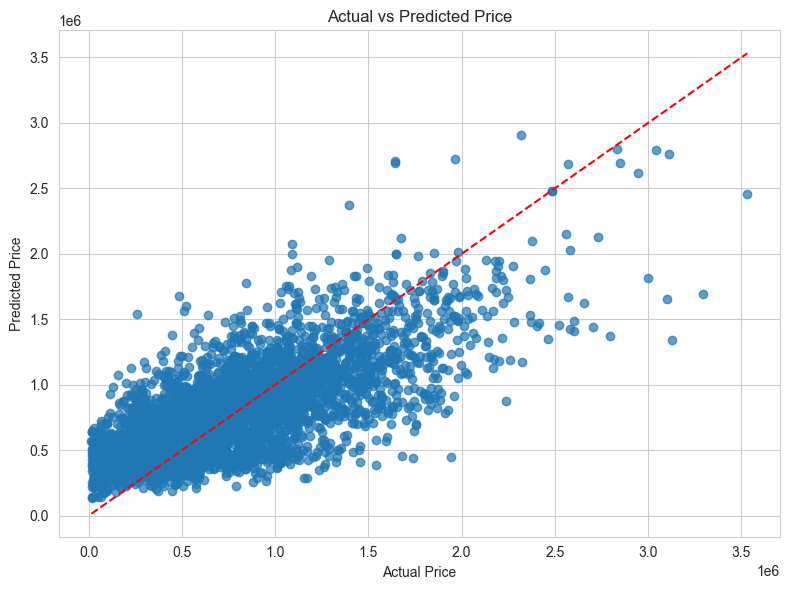

In [8]:
# ============================================================
# Actual vs Predicted Prices
# ============================================================

plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    y_pred,
    alpha=0.7
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linestyle="--"
)

plt.xlabel("Actual Price")

plt.ylabel("Predicted Price")

plt.title("Actual vs Predicted Price")

plt.tight_layout()

plt.show()

### Insight

The closer the points are to the diagonal reference line, the more accurate the revenue predictions.

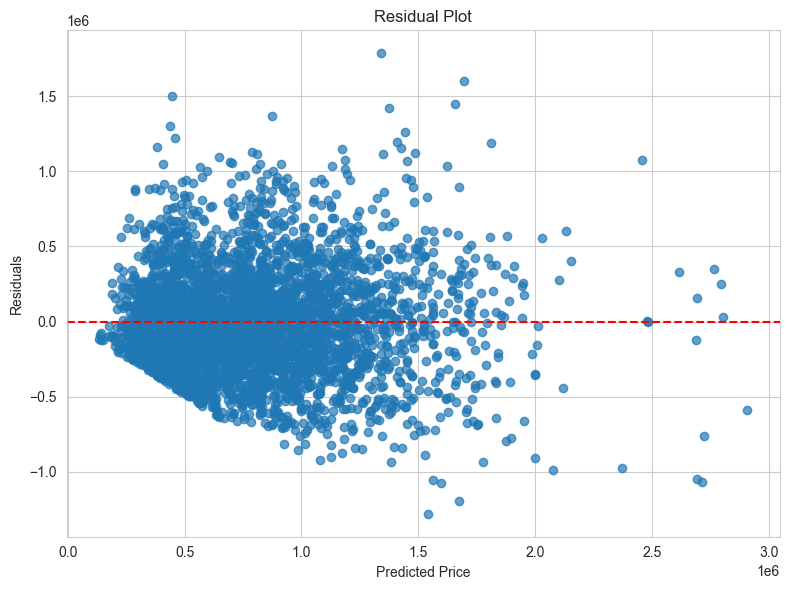

In [9]:
# ============================================================
# Residual Plot
# ============================================================

residuals = y_test - y_pred

plt.figure(figsize=(8,6))

plt.scatter(
    y_pred,
    residuals,
    alpha=0.7
)

plt.axhline(
    0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted Price")

plt.ylabel("Residuals")

plt.title("Residual Plot")

plt.tight_layout()

plt.show()

### Insight

Residuals are randomly distributed around zero, indicating that the model does not exhibit strong systematic prediction bias.

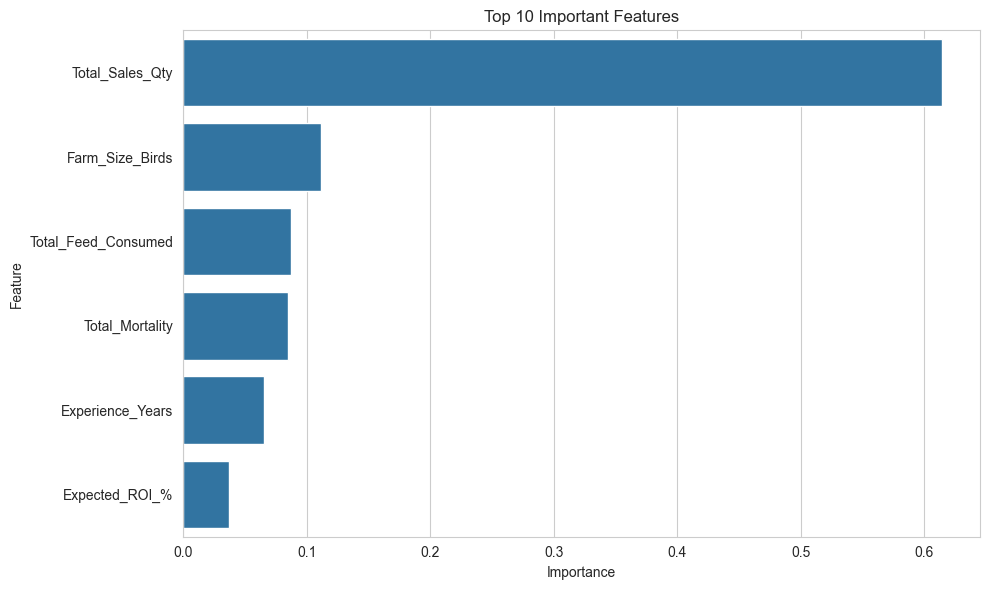

Top 10 Important Features:



,Feature,Importance
3,Total_Sales_Qty,0.614601
0,Farm_Size_Birds,0.111236
2,Total_Feed_Consumed,0.087080
4,Total_Mortality,0.084807
1,Experience_Years,0.065195
5,Expected_ROI_%,0.037081


In [10]:
# ============================================================
# Feature Importance
# ============================================================

if hasattr(best_model, "feature_importances_"):

    feature_importance = pd.DataFrame({

        "Feature": X.columns,

        "Importance": best_model.feature_importances_

    })

    feature_importance = feature_importance.sort_values(
        by="Importance",
        ascending=False
    )

    plt.figure(figsize=(10,6))

    sns.barplot(
        data=feature_importance.head(10),
        x="Importance",
        y="Feature"
    )

    plt.title("Top 10 Important Features")

    plt.tight_layout()

    plt.show()

    print("Top 10 Important Features:\n")

    display(feature_importance.head(10))

else:

    print("Feature importance is not available for Linear Regression.")

In [11]:
# ============================================================
# Save Price Prediction Model
# ============================================================

joblib.dump(
    best_model,
    "../models/price_prediction.pkl"
)

print("Price Prediction Model Saved Successfully.")

Price Prediction Model Saved Successfully.


In [12]:
import joblib

price_features = joblib.load("../models/price_feature_columns.pkl")
print(price_features)

['Farm_Size_Birds', 'Experience_Years', 'Total_Feed_Consumed', 'Total_Sales_Qty', 'Total_Mortality', 'Expected_ROI_%']


# Notebook Conclusion

In this notebook:

- Built three regression models for price prediction.
- Compared their performance using MAE, RMSE, and R² Score.
- Selected the best-performing model.
- Evaluated prediction accuracy.
- Visualized Actual vs Predicted prices.
- Analyzed residual errors.
- Identified the most important pricing features.
- Saved the trained model for deployment.